<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-8/blob/main/Ejercicio2_Clustering_Jerarquico_Mall_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏬 Segmentación de Clientes con Clustering Jerárquico
## Dataset: Mall Customers
---

**Objetivo:** Aplicar clustering jerárquico aglomerativo con diferentes métodos de *linkage* para segmentar clientes de un centro comercial. Analizar cómo el método de vinculación afecta los grupos resultantes y extraer insights de negocio.

**Dataset:** 200 clientes con variables demográficas y de comportamiento de compra.

| Variable | Descripción |
|---|---|
| `CustomerID` | ID único del cliente |
| `Gender` | Género (M/F) |
| `Age` | Edad |
| `Education` | Nivel educativo |
| `Marital Status` | Estado civil |
| `Annual Income (k$)` | Ingreso anual en miles de dólares |
| `Spending Score (1-100)` | Puntuación de gasto asignada por el mall |

**Referencia conceptual:** Mayenka Fernández Chambi — *Aprendizaje No Supervisado / Clustering Jerárquico*

## 0. Instalación de librerías *(solo si es necesario en Colab)*

In [1]:
!pip install scikit-learn matplotlib seaborn pandas scipy --quiet

## 1. Importación de librerías

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Clustering jerárquico — scikit-learn
from sklearn.cluster import AgglomerativeClustering

# Clustering jerárquico — scipy (para dendrogramas)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# Métricas internas
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Estilo visual
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#E67E22']

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Carga y exploración del dataset

In [4]:
URL = 'https://raw.githubusercontent.com/bismarxx/Machine-Learning-I-Actividad-8/refs/heads/main/Mall_Customers.csv'
df = pd.read_csv(URL)

# Limpiar nombre de columnas (hay espacios)
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}  ({df.shape[0]} clientes, {df.shape[1]} variables)')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
df.head(10)

Shape: (200, 7)  (200 clientes, 7 variables)

Columnas: ['CustomerID', 'Gender', 'Age', 'Education', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']

Valores nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40
5,6,F,22,Graduate,Married,17,76
6,7,F,35,Unknown,Married,18,6
7,8,F,23,High School,Unknown,18,94
8,9,M,64,Uneducated,Single,19,3
9,10,F,30,Graduate,Single,19,72


In [5]:
print('Estadísticas descriptivas (variables numéricas):')
df.describe().round(2)

Estadísticas descriptivas (variables numéricas):


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [6]:
print('Distribución de variables categóricas:')
print()
for col in ['Gender', 'Education', 'Marital Status']:
    print(f'  {col}:')
    print(df[col].value_counts().to_string(index=True))
    print()

Distribución de variables categóricas:

  Gender:
Gender
F    112
M     88

  Education:
Education
Graduate         67
High School      40
Uneducated       31
Unknown          26
College          17
Doctorate        11
Post-Graduate     8

  Marital Status:
Marital Status
Married     112
Single       61
Unknown      15
Divorced     12



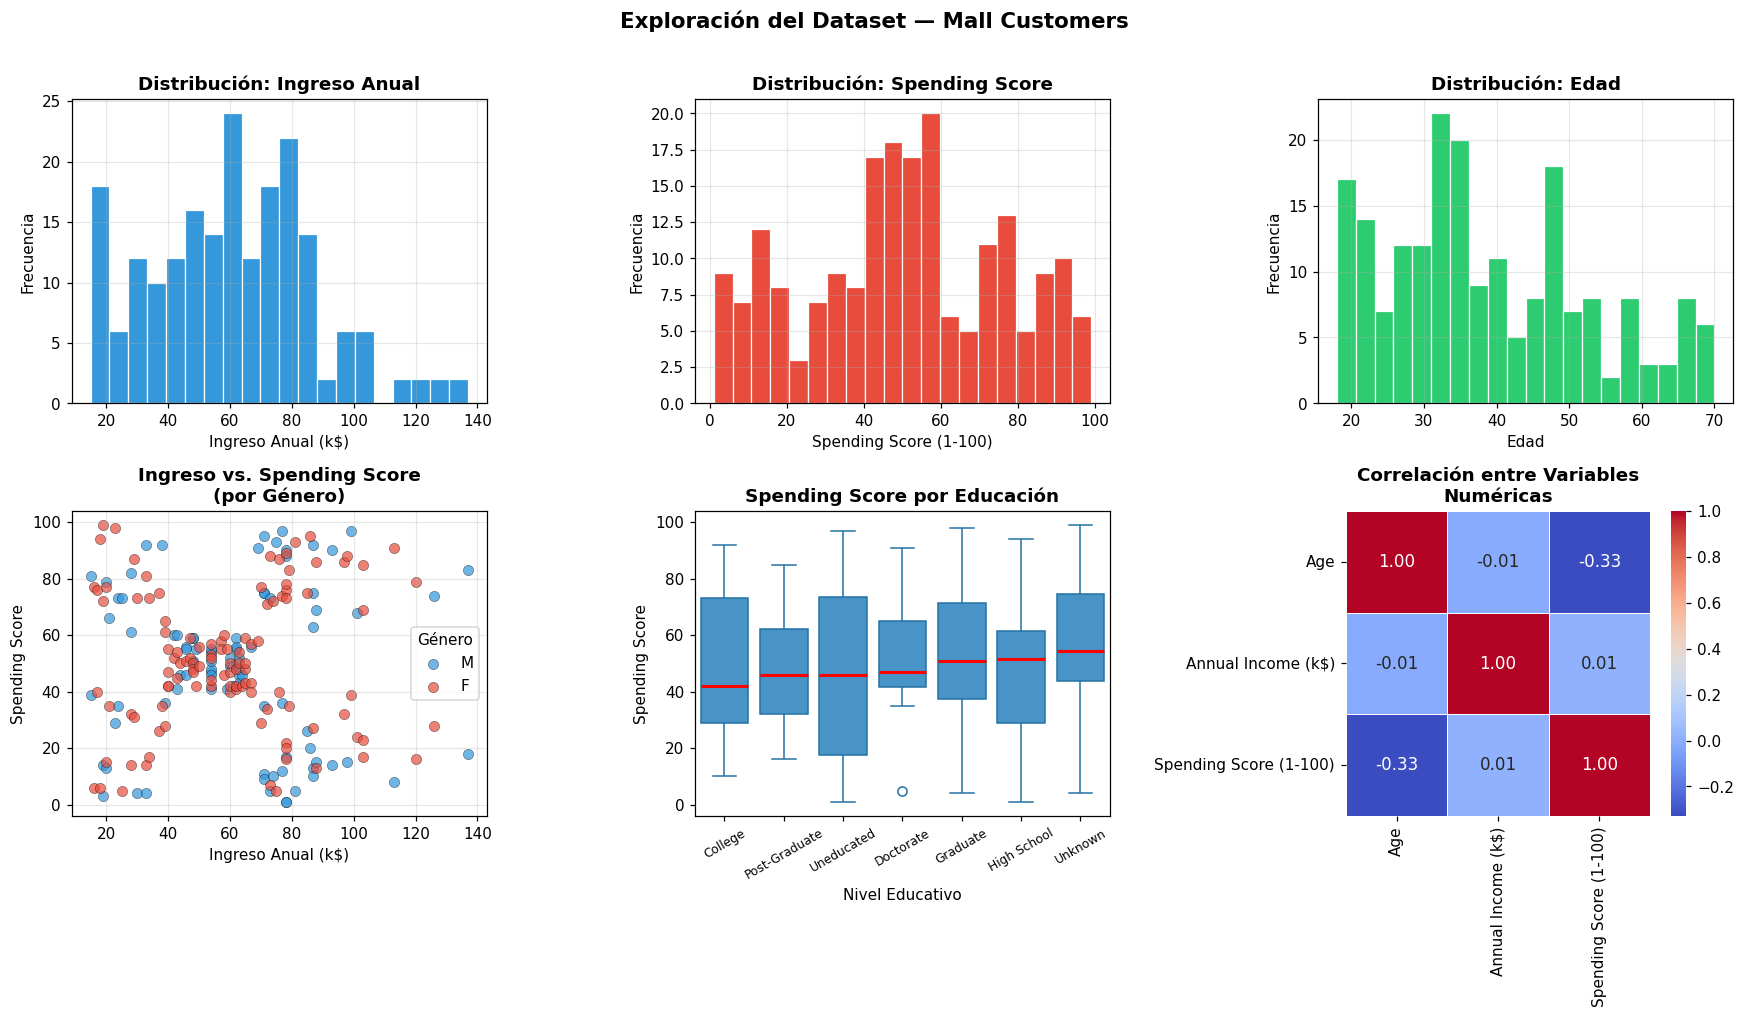

In [9]:
# ── Visualización exploratoria ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Distribución de Ingresos
axes[0,0].hist(df['Annual Income (k$)'], bins=20, color='#3498DB', edgecolor='white', linewidth=0.8)
axes[0,0].set_title('Distribución: Ingreso Anual', fontweight='bold')
axes[0,0].set_xlabel('Ingreso Anual (k$)'); axes[0,0].set_ylabel('Frecuencia')
axes[0,0].grid(True, alpha=0.3)

# 2. Distribución de Spending Score
axes[0,1].hist(df['Spending Score (1-100)'], bins=20, color='#E74C3C', edgecolor='white', linewidth=0.8)
axes[0,1].set_title('Distribución: Spending Score', fontweight='bold')
axes[0,1].set_xlabel('Spending Score (1-100)'); axes[0,1].set_ylabel('Frecuencia')
axes[0,1].grid(True, alpha=0.3)

# 3. Distribución de Edad
axes[0,2].hist(df['Age'], bins=20, color='#2ECC71', edgecolor='white', linewidth=0.8)
axes[0,2].set_title('Distribución: Edad', fontweight='bold')
axes[0,2].set_xlabel('Edad'); axes[0,2].set_ylabel('Frecuencia')
axes[0,2].grid(True, alpha=0.3)

# 4. Scatter: Ingreso vs Spending Score (coloreado por Género)
colors_gender = {'M': '#3498DB', 'F': '#E74C3C'}
for g, c in colors_gender.items():
    mask = df['Gender'] == g
    axes[1,0].scatter(df.loc[mask,'Annual Income (k$)'],
                      df.loc[mask,'Spending Score (1-100)'],
                      c=c, label=g, alpha=0.7, s=45, edgecolors='k', linewidths=0.3)
axes[1,0].set_title('Ingreso vs. Spending Score\n(por Género)', fontweight='bold')
axes[1,0].set_xlabel('Ingreso Anual (k$)'); axes[1,0].set_ylabel('Spending Score')
axes[1,0].legend(title='Género'); axes[1,0].grid(True, alpha=0.3)

# 5. Boxplot de Spending Score por Educación — CORREGIDO con seaborn
edu_order = (df.groupby('Education')['Spending Score (1-100)']
               .median()
               .sort_values()
               .index.tolist())
sns.boxplot(
    data=df, x='Education', y='Spending Score (1-100)',
    order=edu_order, ax=axes[1,1],
    color='#3498DB', linecolor='#2471A3',
    medianprops=dict(color='red', linewidth=2)
)
axes[1,1].set_title('Spending Score por Educación', fontweight='bold')
axes[1,1].set_xlabel('Nivel Educativo'); axes[1,1].set_ylabel('Spending Score')
axes[1,1].tick_params(axis='x', rotation=30, labelsize=8)

# 6. Correlación
corr = df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,2], square=True, linewidths=0.5,
            annot_kws={'size': 11})
axes[1,2].set_title('Correlación entre Variables\nNuméricas', fontweight='bold')

fig.suptitle('Exploración del Dataset — Mall Customers', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Para el clustering jerárquico usaremos las dos variables de mayor poder discriminativo en segmentación de clientes:
- **Ingreso Anual** (`Annual Income`) → capacidad económica
- **Spending Score** → comportamiento de compra

Estas dos variables forman el espacio clásico de segmentación de clientes de mall.  
Luego realizaremos un análisis adicional incluyendo `Age`.

> **¿Por qué estandarizar?**  
> El clustering jerárquico usa distancias euclidianas. Si `Annual Income` varía en rango [15–137]  
> y `Spending Score` en [1–99], la distancia estará dominada por la variable de mayor magnitud.

In [11]:
# ── Features a usar ───────────────────────────────────────────────────────────
features_2d = ['Annual Income (k$)', 'Spending Score (1-100)']
features_3d = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X2 = df[features_2d].values
X3 = df[features_3d].values

# Estandarización
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

print('Varianzas ANTES de escalar (X2):')
for i, f in enumerate(features_2d):
    print(f'   {f}: varianza = {np.var(X2[:, i]):.2f}')
print()
print('Varianzas DESPUÉS de escalar (X2_scaled):')
for i, f in enumerate(features_2d):
    print(f'   {f}: varianza = {np.var(X2_scaled[:, i]):.2f}')
print()
print('Datos listos para clustering.')

Varianzas ANTES de escalar (X2):
   Annual Income (k$): varianza = 686.39
   Spending Score (1-100): varianza = 663.52

Varianzas DESPUÉS de escalar (X2_scaled):
   Annual Income (k$): varianza = 1.00
   Spending Score (1-100): varianza = 1.00

Datos listos para clustering.


## 4. Determinación del número óptimo de clusters
### 4.1 Dendrograma completo — primera exploración

El dendrograma nos permite **visualizar la jerarquía completa de fusiones** antes de decidir cuántos clusters cortar.  
La altura de cada fusión corresponde a la **distancia entre los grupos fusionados**.

> **Regla del corte:** Identificar el salto más grande en la escala vertical — ese es el número óptimo de clusters.

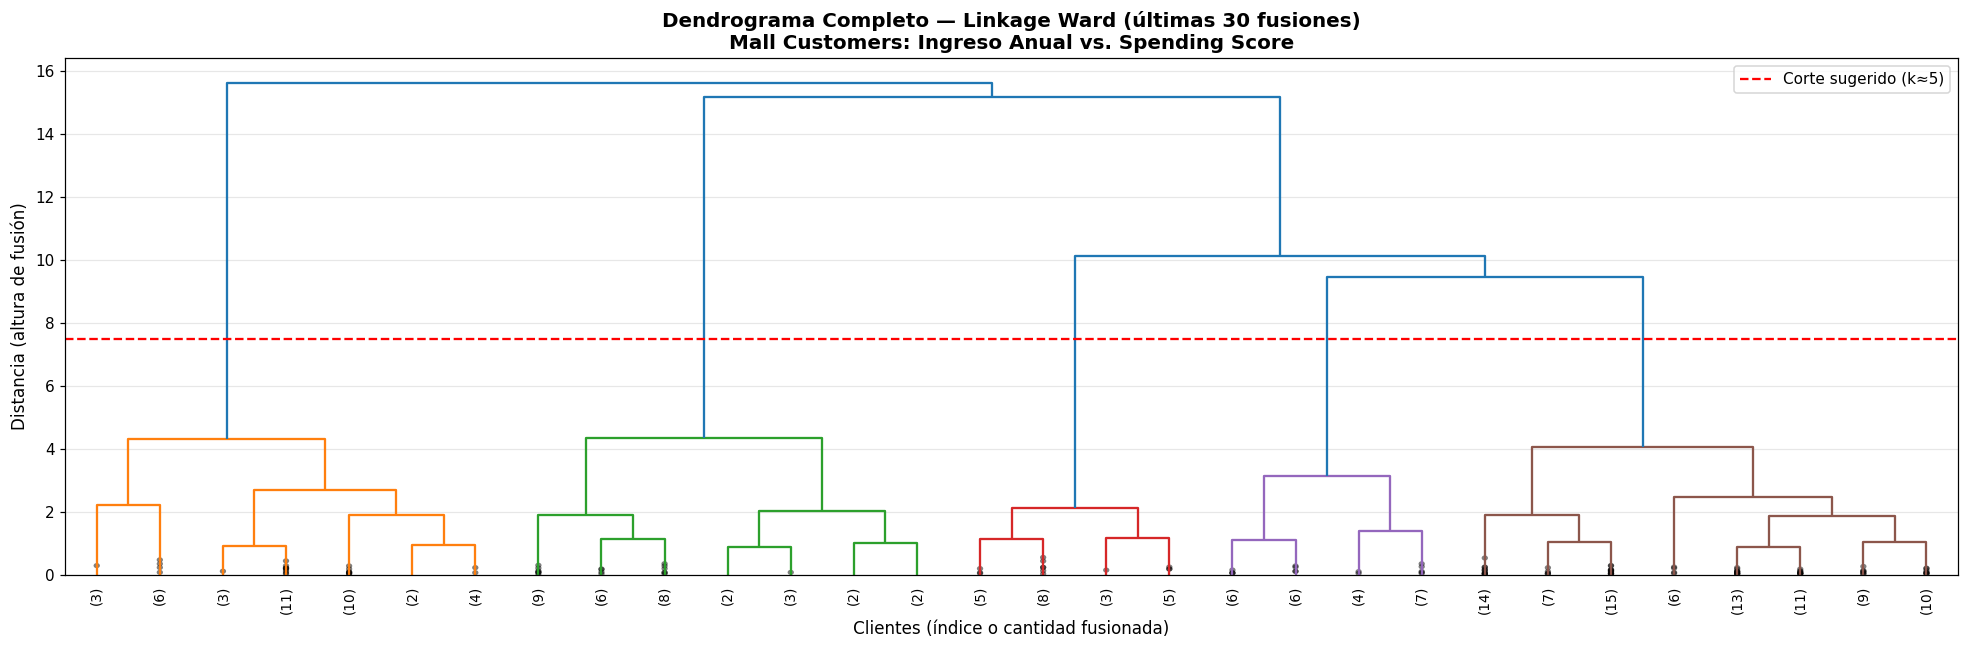


INTERPRETACIÓN:
   • Cada línea vertical = un cluster en ese nivel de altura
   • Los saltos más grandes en altura = fusiones de grupos MUY distintos
   • El mayor salto sugiere cuántos clusters naturales existen en los datos
   • En este caso, el corte a altura ~7.5 sugiere k=5 clusters


In [13]:
# Calcular linkage con método 'ward' para exploración inicial
Z_ward = linkage(X2_scaled, method='ward')

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(
    Z_ward,
    ax=ax,
    truncate_mode='lastp',   # Mostrar solo las últimas p fusiones
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=7.5
)
ax.axhline(y=7.5, color='red', linestyle='--', linewidth=1.5, label='Corte sugerido (k≈5)')
ax.set_title('Dendrograma Completo — Linkage Ward (últimas 30 fusiones)\n'
             'Mall Customers: Ingreso Anual vs. Spending Score',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Clientes (índice o cantidad fusionada)', fontsize=11)
ax.set_ylabel('Distancia (altura de fusión)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nINTERPRETACIÓN:')
print('   • Cada línea vertical = un cluster en ese nivel de altura')
print('   • Los saltos más grandes en altura = fusiones de grupos MUY distintos')
print('   • El mayor salto sugiere cuántos clusters naturales existen en los datos')
print('   • En este caso, el corte a altura ~7.5 sugiere k=5 clusters')

In [15]:
# Análisis de los últimos saltos de distancia
ultimas_fusiones = Z_ward[-10:, 2]  # Últimas 10 distancias de fusión
aceleracion = np.diff(ultimas_fusiones)  # Diferencias entre distancias consecutivas
k_sugerido = aceleracion.argmax() + 2   # k = posición del mayor salto + 2

print('Últimas 10 distancias de fusión (Ward):')
for i, d in enumerate(ultimas_fusiones):
    marca = ' ◄ MAYOR SALTO' if i == aceleracion.argmax() + 1 else ''
    print(f'   Fusión {10-i:2d} desde el final: distancia = {d:.4f}{marca}')

print(f'\nK óptimo sugerido por el criterio del mayor salto: k = {k_sugerido}')

Últimas 10 distancias de fusión (Ward):
   Fusión 10 desde el final: distancia = 2.4875
   Fusión  9 desde el final: distancia = 2.6981
   Fusión  8 desde el final: distancia = 3.1503
   Fusión  7 desde el final: distancia = 4.0725
   Fusión  6 desde el final: distancia = 4.3081
   Fusión  5 desde el final: distancia = 4.3544
   Fusión  4 desde el final: distancia = 9.4534 ◄ MAYOR SALTO
   Fusión  3 desde el final: distancia = 10.1413
   Fusión  2 desde el final: distancia = 15.1862
   Fusión  1 desde el final: distancia = 15.6248

K óptimo sugerido por el criterio del mayor salto: k = 7


## 5. Los 4 métodos de Linkage

El método de **linkage** (vinculación) define **cómo se mide la distancia entre dos clusters** durante el proceso de fusión aglomerativa.

| Linkage | Distancia entre clusters A y B | Sensibilidad |
|---|---|---|
| **Ward** | Minimiza el incremento de la varianza total intra-cluster | Outliers: baja — produce clusters compactos y equilibrados |
| **Complete** | Distancia **máxima** entre cualquier par de puntos de A y B | Outliers: alta — tiende a clusters compactos |
| **Average** | Distancia **promedio** entre todos los pares de puntos de A y B | Equilibrado — compromiso entre Single y Complete |
| **Single** | Distancia **mínima** entre cualquier par de puntos de A y B | Outliers: muy alta — efecto cadena (*chaining effect*) |

> ⚠️ **Distintos linkages → distinto agrupamiento jerárquico** (Fernández Chambi, 2024)

In [17]:
# ── Calcular linkages ─────────────────────────────────────────────────────────
LINKAGES = ['ward', 'complete', 'average', 'single']
K_OPTIMO = 5  # Definido por el análisis del dendrograma

# Matrices de linkage (scipy) para dendrogramas
Z_matrices = {}
for method in LINKAGES:
    Z_matrices[method] = linkage(X2_scaled, method=method)
    print(f'  Linkage {method:8s} calculado — '
          f'rango de distancias: [{Z_matrices[method][:,2].min():.3f}, {Z_matrices[method][:,2].max():.3f}]')

  Linkage ward     calculado — rango de distancias: [0.000, 15.625]
  Linkage complete calculado — rango de distancias: [0.000, 5.501]
  Linkage average  calculado — rango de distancias: [0.000, 2.311]
  Linkage single   calculado — rango de distancias: [0.000, 0.572]


### 5.1 Dendrogramas de los 4 linkages — comparación

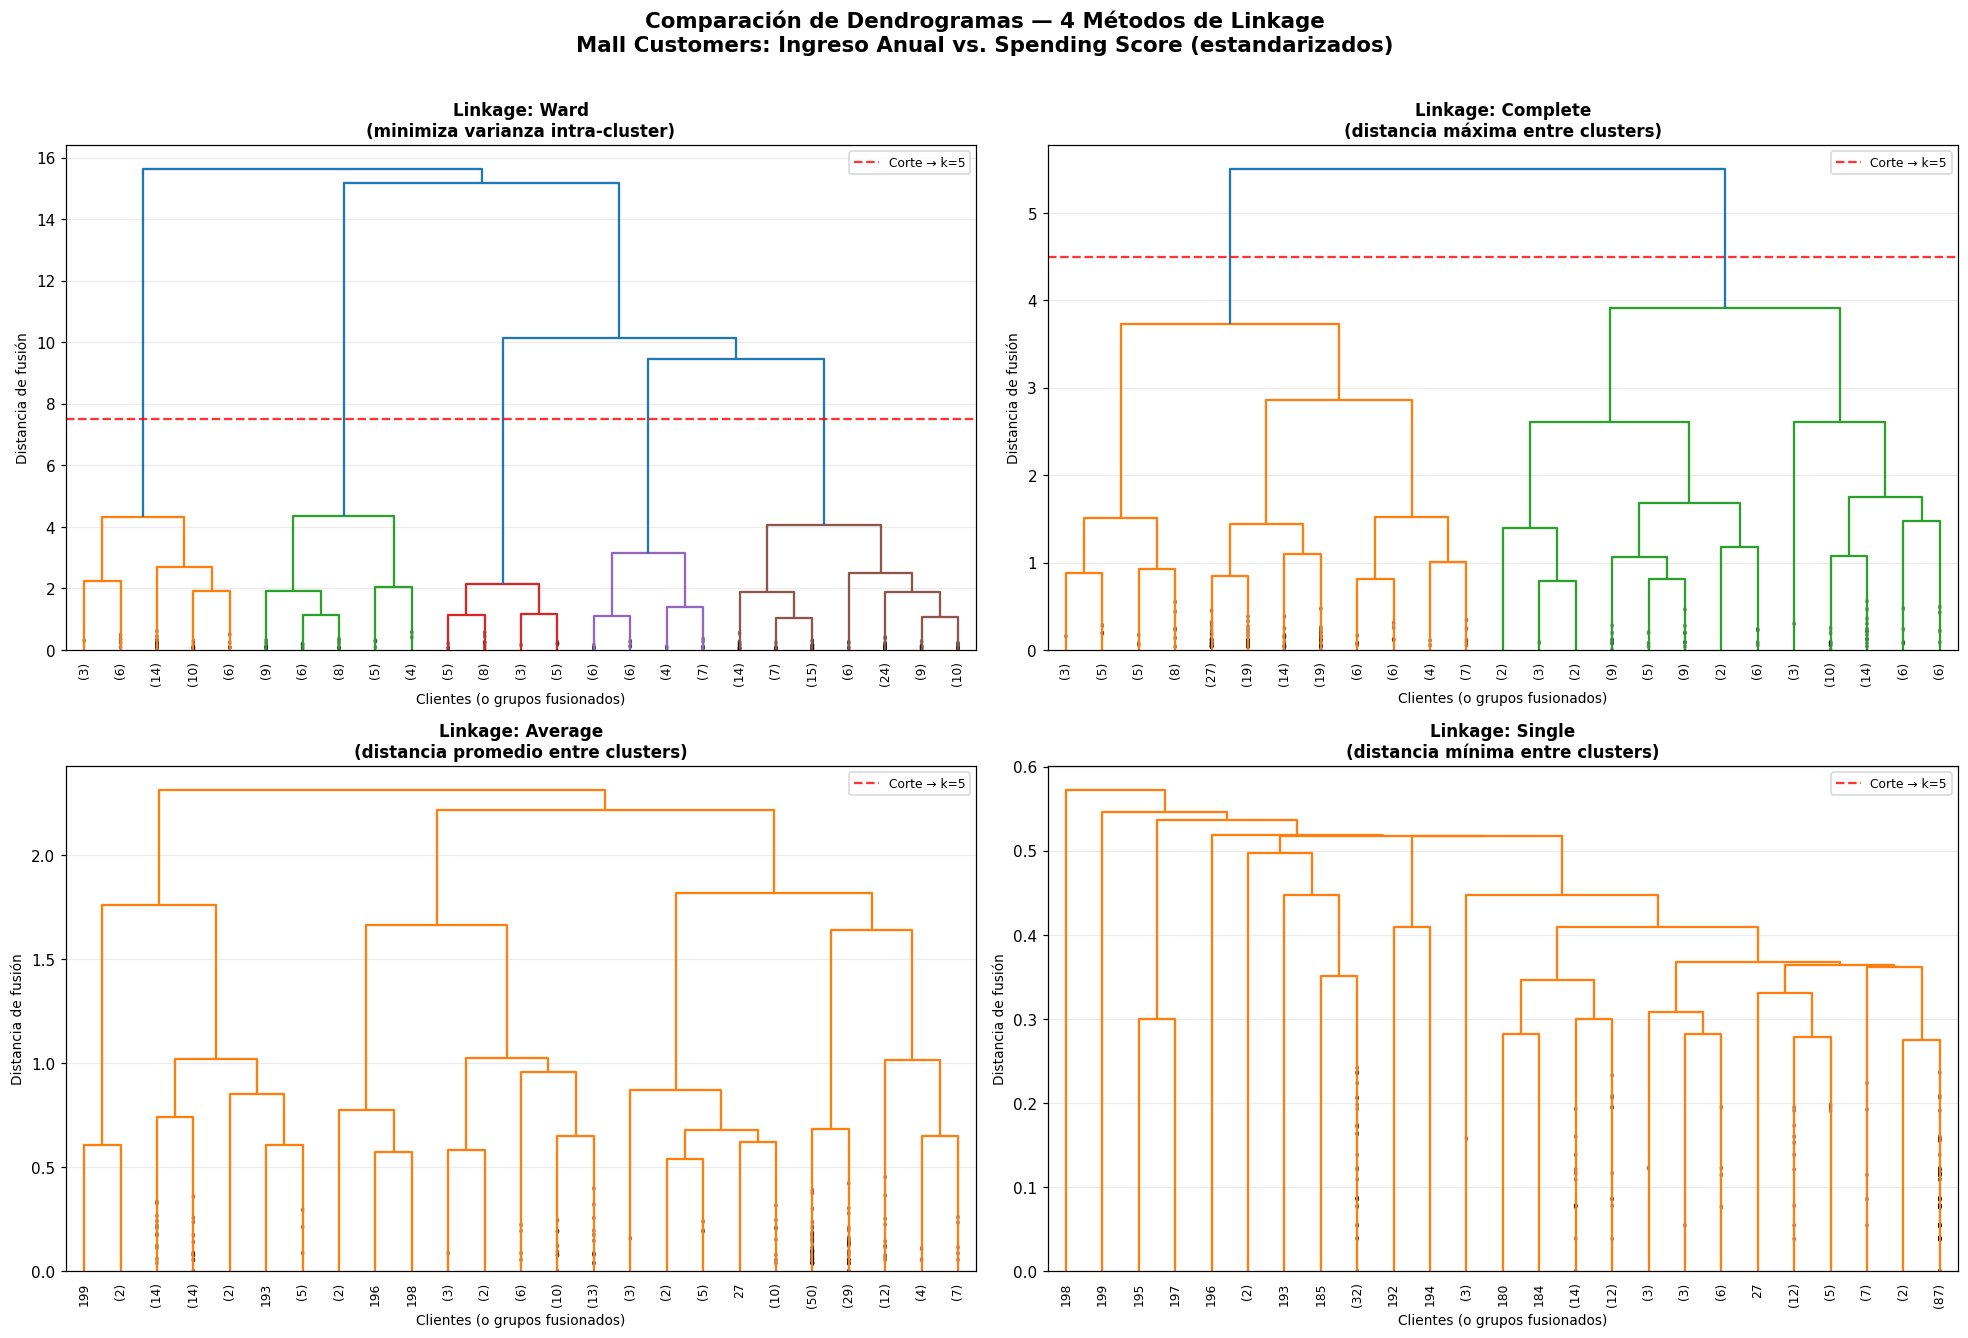

In [18]:
TITULOS = {
    'ward'    : 'Ward\n(minimiza varianza intra-cluster)',
    'complete': 'Complete\n(distancia máxima entre clusters)',
    'average' : 'Average\n(distancia promedio entre clusters)',
    'single'  : 'Single\n(distancia mínima entre clusters)'
}
COLORES_CORTE = {
    'ward': 7.5, 'complete': 4.5, 'average': 2.5, 'single': 1.2
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, method in zip(axes.flatten(), LINKAGES):
    dendrogram(
        Z_matrices[method],
        ax=ax,
        truncate_mode='lastp',
        p=25,
        leaf_rotation=90,
        leaf_font_size=8,
        show_contracted=True,
        color_threshold=COLORES_CORTE[method]
    )
    ax.axhline(y=COLORES_CORTE[method], color='red',
               linestyle='--', linewidth=1.5, alpha=0.8,
               label=f'Corte → k={K_OPTIMO}')
    ax.set_title(f'Linkage: {TITULOS[method]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Clientes (o grupos fusionados)', fontsize=9)
    ax.set_ylabel('Distancia de fusión', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.25)

fig.suptitle('Comparación de Dendrogramas — 4 Métodos de Linkage\n'
             'Mall Customers: Ingreso Anual vs. Spending Score (estandarizados)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Entrenamiento con AgglomerativeClustering (k=5)

In [20]:
# Entrenar AgglomerativeClustering con cada linkage
modelos = {}
etiquetas = {}

for method in LINKAGES:
    modelo = AgglomerativeClustering(
        n_clusters=K_OPTIMO,
        linkage=method,
        metric='euclidean'   # 'metric' reemplaza a 'affinity' en versiones recientes
    )
    labels = modelo.fit_predict(X2_scaled)
    modelos[method] = modelo
    etiquetas[method] = labels
    conteo = dict(zip(*np.unique(labels, return_counts=True)))
    print(f'  {method:8s}: distribución de clusters = {conteo}')

  ward    : distribución de clusters = {np.int64(0): np.int64(32), np.int64(1): np.int64(39), np.int64(2): np.int64(85), np.int64(3): np.int64(21), np.int64(4): np.int64(23)}
  complete: distribución de clusters = {np.int64(0): np.int64(39), np.int64(1): np.int64(23), np.int64(2): np.int64(38), np.int64(3): np.int64(21), np.int64(4): np.int64(79)}
  average : distribución de clusters = {np.int64(0): np.int64(38), np.int64(1): np.int64(102), np.int64(2): np.int64(36), np.int64(3): np.int64(21), np.int64(4): np.int64(3)}
  single  : distribución de clusters = {np.int64(0): np.int64(195), np.int64(1): np.int64(2), np.int64(2): np.int64(1), np.int64(3): np.int64(1), np.int64(4): np.int64(1)}


### 5.3 Visualización de segmentos — los 4 linkages

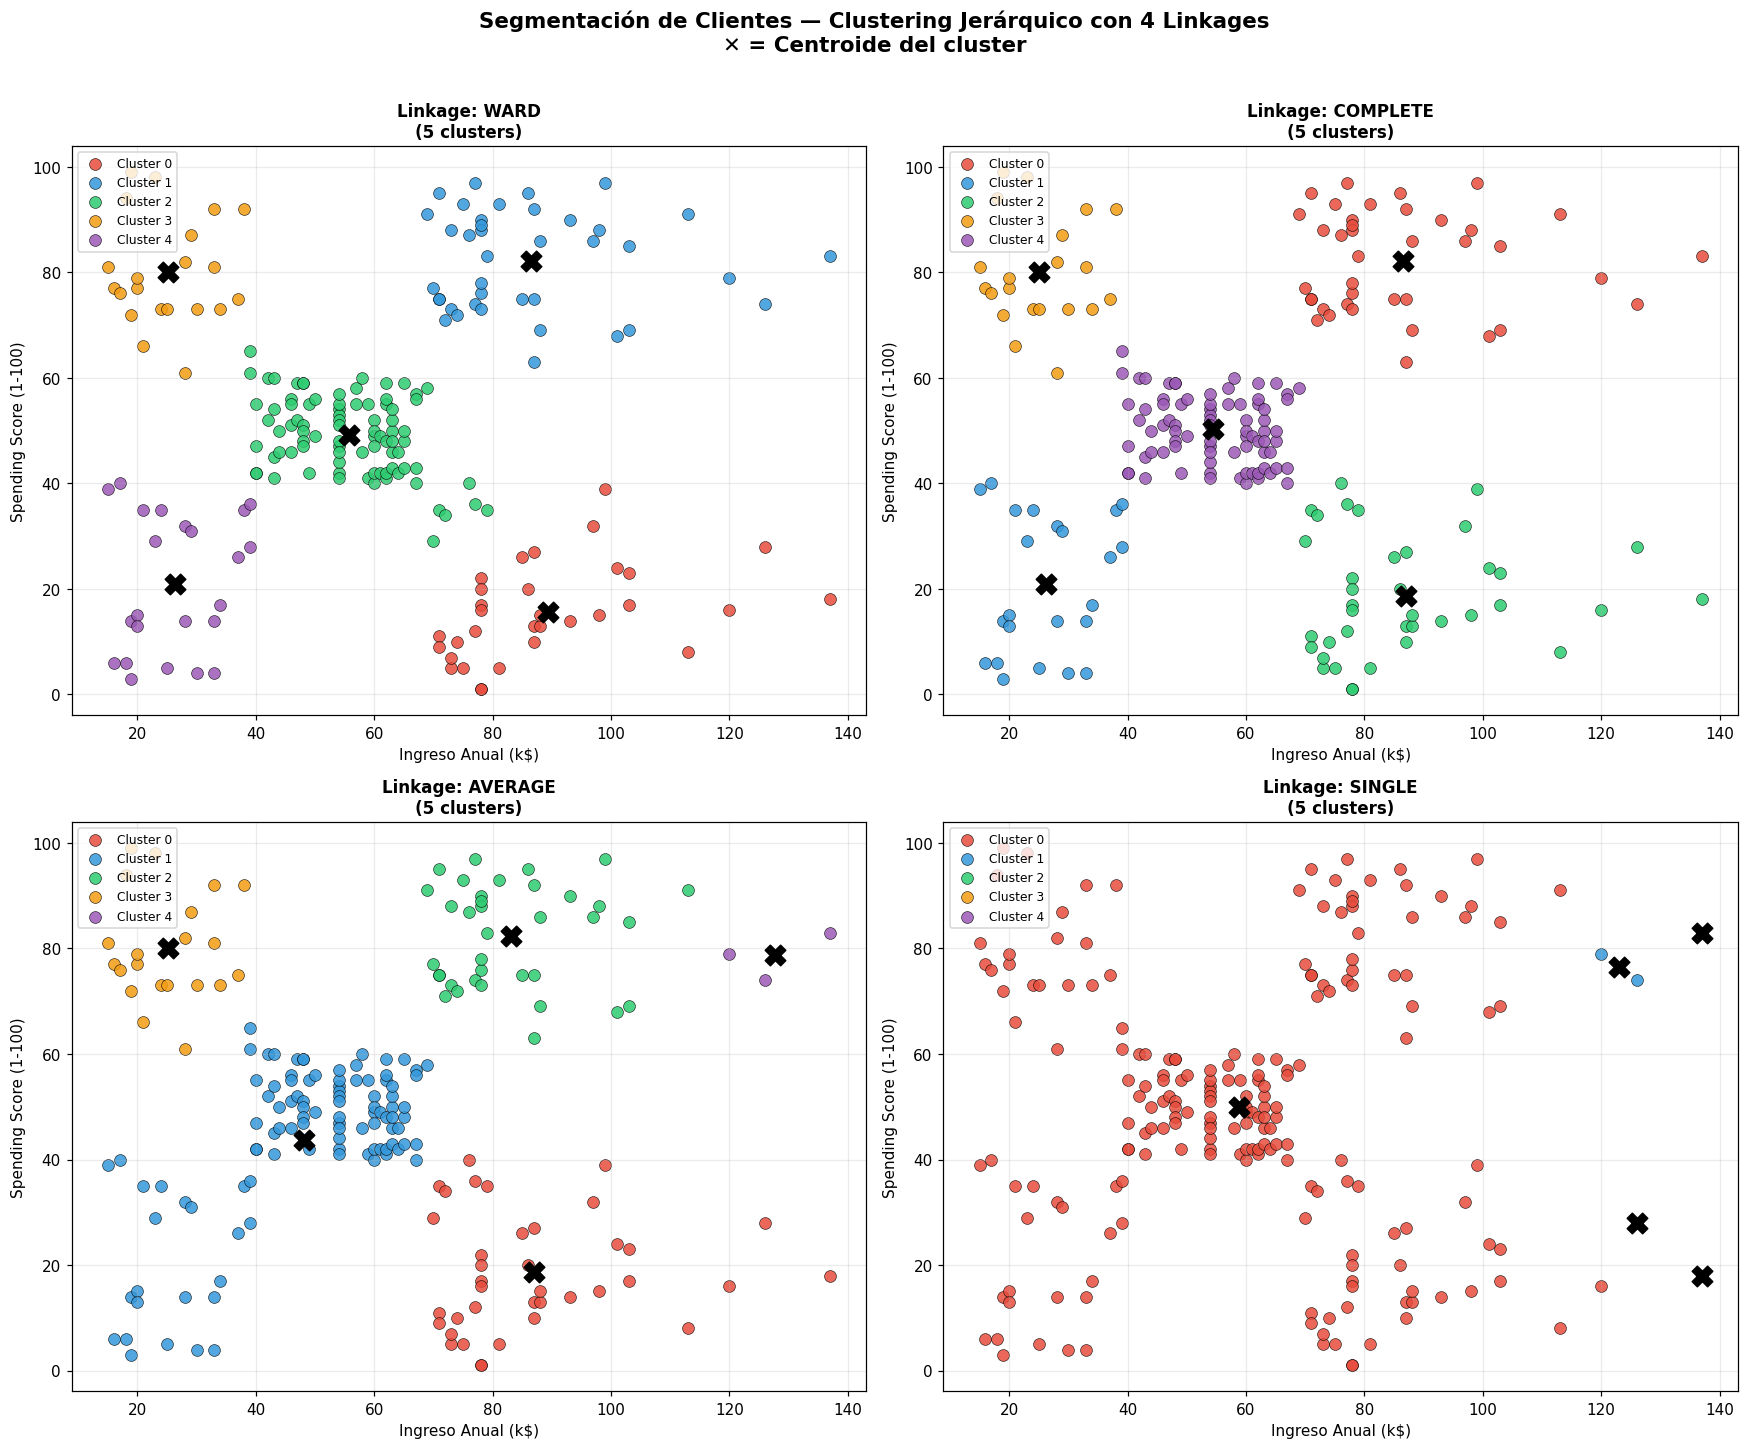

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

for ax, method in zip(axes.flatten(), LINKAGES):
    labels = etiquetas[method]
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        ax.scatter(
            X2[mask, 0], X2[mask, 1],
            c=PALETTE[cluster_id % len(PALETTE)],
            label=f'Cluster {cluster_id}',
            s=60, alpha=0.85, edgecolors='k', linewidths=0.4
        )
    # Calcular y marcar centroides visuales
    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        cx = X2[mask, 0].mean()
        cy = X2[mask, 1].mean()
        ax.scatter(cx, cy, c='black', marker='X', s=180, zorder=5)

    ax.set_title(f'Linkage: {method.upper()}\n({K_OPTIMO} clusters)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Ingreso Anual (k$)', fontsize=10)
    ax.set_ylabel('Spending Score (1-100)', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.25)

fig.suptitle('Segmentación de Clientes — Clustering Jerárquico con 4 Linkages\n'
             '✕ = Centroide del cluster',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Métricas de validación interna

Comparamos la **calidad de clustering** de cada linkage usando métricas internas (sin etiquetas reales):

| Métrica | ¿Qué mide? | Mejor valor |
|---|---|---|
| **Silhouette Score** | Cohesión y separación de clusters | +1 (mayor es mejor) |
| **Calinski-Harabasz** | Ratio varianza inter vs intra-cluster | Mayor es mejor |
| **Davies-Bouldin** | Similitud promedio entre clusters | Menor es mejor |

In [23]:
resultados = []
for method in LINKAGES:
    labels = etiquetas[method]
    n_cls  = len(np.unique(labels))
    if n_cls < 2:
        print(f'{method}: solo {n_cls} cluster — métricas no aplicables')
        continue
    sil = silhouette_score(X2_scaled, labels)
    cal = calinski_harabasz_score(X2_scaled, labels)
    dav = davies_bouldin_score(X2_scaled, labels)
    resultados.append({
        'Linkage'              : method.capitalize(),
        'Clusters'             : n_cls,
        'Silhouette ↑'         : round(sil, 4),
        'Calinski-Harabasz ↑'  : round(cal, 2),
        'Davies-Bouldin ↓'     : round(dav, 4)
    })

df_metricas = pd.DataFrame(resultados).set_index('Linkage')
print('MÉTRICAS INTERNAS DE VALIDACIÓN:')
print('   ↑ Mayor es mejor   ↓ Menor es mejor')
print()
df_metricas

MÉTRICAS INTERNAS DE VALIDACIÓN:
   ↑ Mayor es mejor   ↓ Menor es mejor



,Clusters,Silhouette ↑,Calinski-Harabasz ↑,Davies-Bouldin ↓
Linkage,,,,
Ward,5,0.5538,244.41,0.5779
Complete,5,0.5531,247.21,0.5680
Average,5,0.4794,143.59,0.6433
Single,5,0.2758,5.65,0.4231


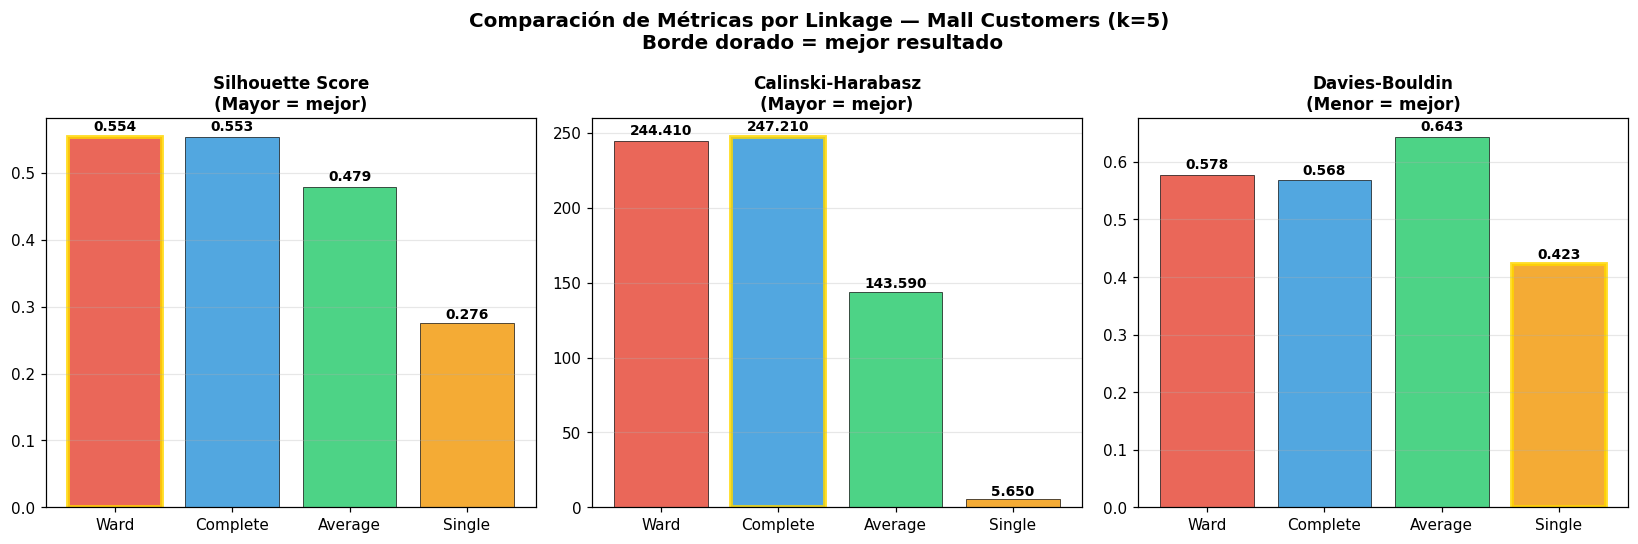


Mejor Silhouette      : Ward (0.5538)
Mejor Calinski-Harabasz: Complete (247.21)
Mejor Davies-Bouldin   : Single (0.4231)


In [25]:
# Visualización de métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = [PALETTE[i] for i in range(len(LINKAGES))]
linkage_names = [l.capitalize() for l in LINKAGES]
x = np.arange(len(linkage_names))

metricas_config = [
    ('Silhouette ↑', axes[0], 'Silhouette Score\n(Mayor = mejor)', True),
    ('Calinski-Harabasz ↑', axes[1], 'Calinski-Harabasz\n(Mayor = mejor)', True),
    ('Davies-Bouldin ↓', axes[2], 'Davies-Bouldin\n(Menor = mejor)', False),
]

for col, ax, title, mayor_mejor in metricas_config:
    vals = df_metricas[col].values
    bars = ax.bar(x, vals, color=bar_colors, edgecolor='k', linewidth=0.5, alpha=0.85)
    # Destacar el mejor
    best_idx = np.argmax(vals) if mayor_mejor else np.argmin(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    # Etiquetas de valor
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 * val,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticks(x); ax.set_xticklabels(linkage_names, fontsize=10)
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Comparación de Métricas por Linkage — Mall Customers (k=5)\n'
             ' Borde dorado = mejor resultado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mejor_sil = df_metricas['Silhouette ↑'].idxmax()
mejor_cal = df_metricas['Calinski-Harabasz ↑'].idxmax()
mejor_dav = df_metricas['Davies-Bouldin ↓'].idxmin()
print(f'\nMejor Silhouette      : {mejor_sil} ({df_metricas.loc[mejor_sil,"Silhouette ↑"]})')
print(f'Mejor Calinski-Harabasz: {mejor_cal} ({df_metricas.loc[mejor_cal,"Calinski-Harabasz ↑"]})')
print(f'Mejor Davies-Bouldin   : {mejor_dav} ({df_metricas.loc[mejor_dav,"Davies-Bouldin ↓"]})')

## 7. Análisis profundo — Linkage Ward (mejor resultado)

Tomamos el clustering con **Ward** (mejor desempeño según métricas) para interpretación de negocio.

In [27]:
# Agregar etiquetas Ward al DataFrame original
df['Cluster_Ward'] = etiquetas['ward']

# Perfil promedio de cada cluster
perfil = df.groupby('Cluster_Ward').agg(
    N_Clientes=('CustomerID', 'count'),
    Edad_Prom=('Age', 'mean'),
    Ingreso_Prom=('Annual Income (k$)', 'mean'),
    Score_Prom=('Spending Score (1-100)', 'mean'),
    Edad_Min=('Age', 'min'),
    Edad_Max=('Age', 'max'),
    Ingreso_Min=('Annual Income (k$)', 'min'),
    Ingreso_Max=('Annual Income (k$)', 'max'),
    Score_Min=('Spending Score (1-100)', 'min'),
    Score_Max=('Spending Score (1-100)', 'max'),
).round(1)

print(' Perfil promedio por cluster (Linkage Ward, k=5):')
print()
perfil[['N_Clientes','Edad_Prom','Ingreso_Prom','Score_Prom']]

 Perfil promedio por cluster (Linkage Ward, k=5):



,N_Clientes,Edad_Prom,Ingreso_Prom,Score_Prom
Cluster_Ward,,,,
0,32,41.0,89.4,15.6
1,39,32.7,86.5,82.1
2,85,42.5,55.8,49.1
3,21,25.3,25.1,80.0
4,23,45.2,26.3,20.9


In [29]:
# Asignar nombres de segmentos basados en los perfiles
NOMBRES_SEGMENTOS = {
    0: 'Clientes Premium',
    1: 'Alto Ingreso / Bajo Gasto',
    2: 'Ingreso Medio / Gasto Medio',
    3: 'Bajo Ingreso / Alto Gasto',
    4: 'Bajo Ingreso / Bajo Gasto'
}

# Reasignar nombres según perfiles reales
# (los IDs de cluster pueden variar — los identificamos por las características)
perfiles_simples = perfil[['Ingreso_Prom', 'Score_Prom']].copy()

# Clasificación automática según cuadrante
def clasificar_segmento(row):
    ingreso_alto = row['Ingreso_Prom'] > perfiles_simples['Ingreso_Prom'].mean()
    score_alto   = row['Score_Prom']   > perfiles_simples['Score_Prom'].mean()
    if ingreso_alto and score_alto:    return 'Alto Ingreso / Alto Gasto (Ideales)'
    elif ingreso_alto and not score_alto: return 'Alto Ingreso / Bajo Gasto (Cautelosos)'
    elif not ingreso_alto and score_alto: return 'Bajo Ingreso / Alto Gasto (Entusiastas)'
    elif perfiles_simples['Ingreso_Prom'].median() * 0.85 < row['Ingreso_Prom'] < perfiles_simples['Ingreso_Prom'].median() * 1.15:
        return 'Ingreso Medio / Gasto Medio (Estándar)'
    else: return 'Bajo Ingreso / Bajo Gasto (Economizadores)'

perfil['Segmento'] = perfil.apply(clasificar_segmento, axis=1)
df['Segmento'] = df['Cluster_Ward'].map(perfil['Segmento'])

print('Segmentos identificados:')
for i, row in perfil.iterrows():
    print(f'\n  Cluster {i} → {row["Segmento"]}')
    print(f'    • N clientes  : {int(row["N_Clientes"])}')
    print(f'    • Edad promedio: {row["Edad_Prom"]} años')
    print(f'    • Ingreso prom : ${row["Ingreso_Prom"]}k')
    print(f'    • Score prom   : {row["Score_Prom"]}/100')

Segmentos identificados:

  Cluster 0 → Alto Ingreso / Bajo Gasto (Cautelosos)
    • N clientes  : 32
    • Edad promedio: 41.0 años
    • Ingreso prom : $89.4k
    • Score prom   : 15.6/100

  Cluster 1 → Alto Ingreso / Alto Gasto (Ideales)
    • N clientes  : 39
    • Edad promedio: 32.7 años
    • Ingreso prom : $86.5k
    • Score prom   : 82.1/100

  Cluster 2 → Ingreso Medio / Gasto Medio (Estándar)
    • N clientes  : 85
    • Edad promedio: 42.5 años
    • Ingreso prom : $55.8k
    • Score prom   : 49.1/100

  Cluster 3 → Bajo Ingreso / Alto Gasto (Entusiastas)
    • N clientes  : 21
    • Edad promedio: 25.3 años
    • Ingreso prom : $25.1k
    • Score prom   : 80.0/100

  Cluster 4 → Bajo Ingreso / Bajo Gasto (Economizadores)
    • N clientes  : 23
    • Edad promedio: 45.2 años
    • Ingreso prom : $26.3k
    • Score prom   : 20.9/100


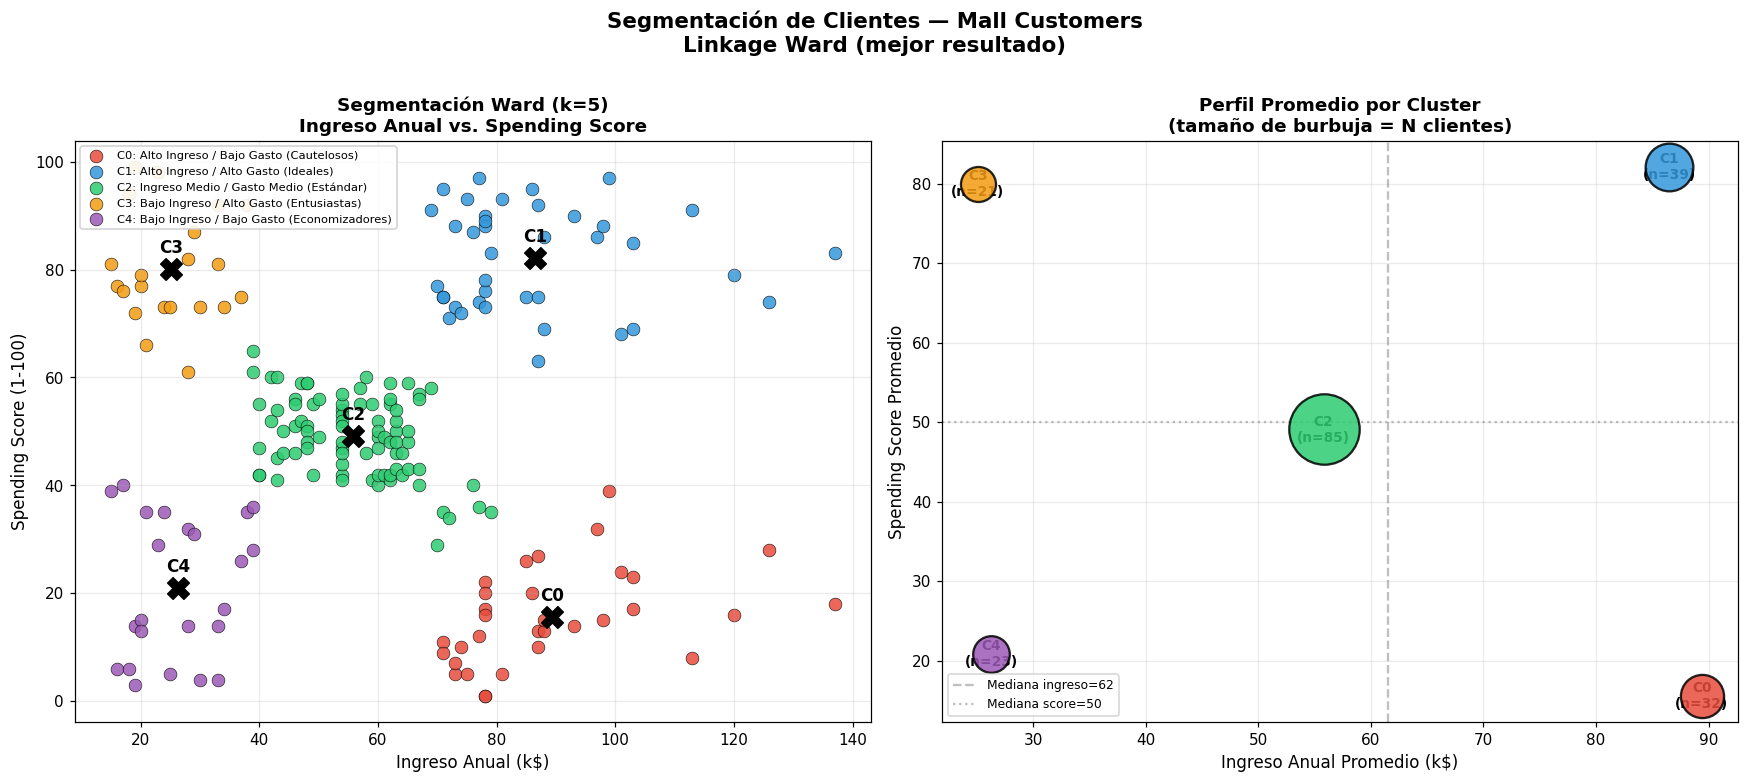

In [30]:
# ── Visualización final: Segmentos con nombres ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: scatter con segmentos
ax = axes[0]
for cluster_id in sorted(df['Cluster_Ward'].unique()):
    mask = df['Cluster_Ward'] == cluster_id
    nombre = perfil.loc[cluster_id, 'Segmento']
    ax.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=PALETTE[cluster_id % len(PALETTE)],
        label=f'C{cluster_id}: {nombre}',
        s=70, alpha=0.85, edgecolors='k', linewidths=0.4
    )
    # Centroide
    cx = df.loc[mask, 'Annual Income (k$)'].mean()
    cy = df.loc[mask, 'Spending Score (1-100)'].mean()
    ax.scatter(cx, cy, c='black', marker='X', s=200, zorder=6)
    ax.annotate(f'C{cluster_id}', (cx, cy), fontsize=11,
                fontweight='bold', ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_title('Segmentación Ward (k=5)\nIngreso Anual vs. Spending Score',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ingreso Anual (k$)', fontsize=11)
ax.set_ylabel('Spending Score (1-100)', fontsize=11)
ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25)

# Panel derecho: bubble chart del perfil
ax2 = axes[1]
for cluster_id in sorted(df['Cluster_Ward'].unique()):
    row = perfil.loc[cluster_id]
    ax2.scatter(
        row['Ingreso_Prom'], row['Score_Prom'],
        s=row['N_Clientes'] * 25,
        c=PALETTE[cluster_id % len(PALETTE)],
        alpha=0.85, edgecolors='k', linewidths=1.5, zorder=5
    )
    ax2.annotate(
        f'C{cluster_id}\n(n={int(row["N_Clientes"])})',
        (row['Ingreso_Prom'], row['Score_Prom']),
        fontsize=9, fontweight='bold', ha='center', va='center'
    )

# Líneas de referencia (medianas)
med_ing = df['Annual Income (k$)'].median()
med_sc  = df['Spending Score (1-100)'].median()
ax2.axvline(med_ing, color='gray', linestyle='--', alpha=0.5, label=f'Mediana ingreso={med_ing:.0f}')
ax2.axhline(med_sc, color='gray', linestyle=':', alpha=0.5, label=f'Mediana score={med_sc:.0f}')

ax2.set_title('Perfil Promedio por Cluster\n(tamaño de burbuja = N clientes)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Ingreso Anual Promedio (k$)', fontsize=11)
ax2.set_ylabel('Spending Score Promedio', fontsize=11)
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)

fig.suptitle('Segmentación de Clientes — Mall Customers\nLinkage Ward (mejor resultado)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Análisis adicional: composición demográfica de cada segmento

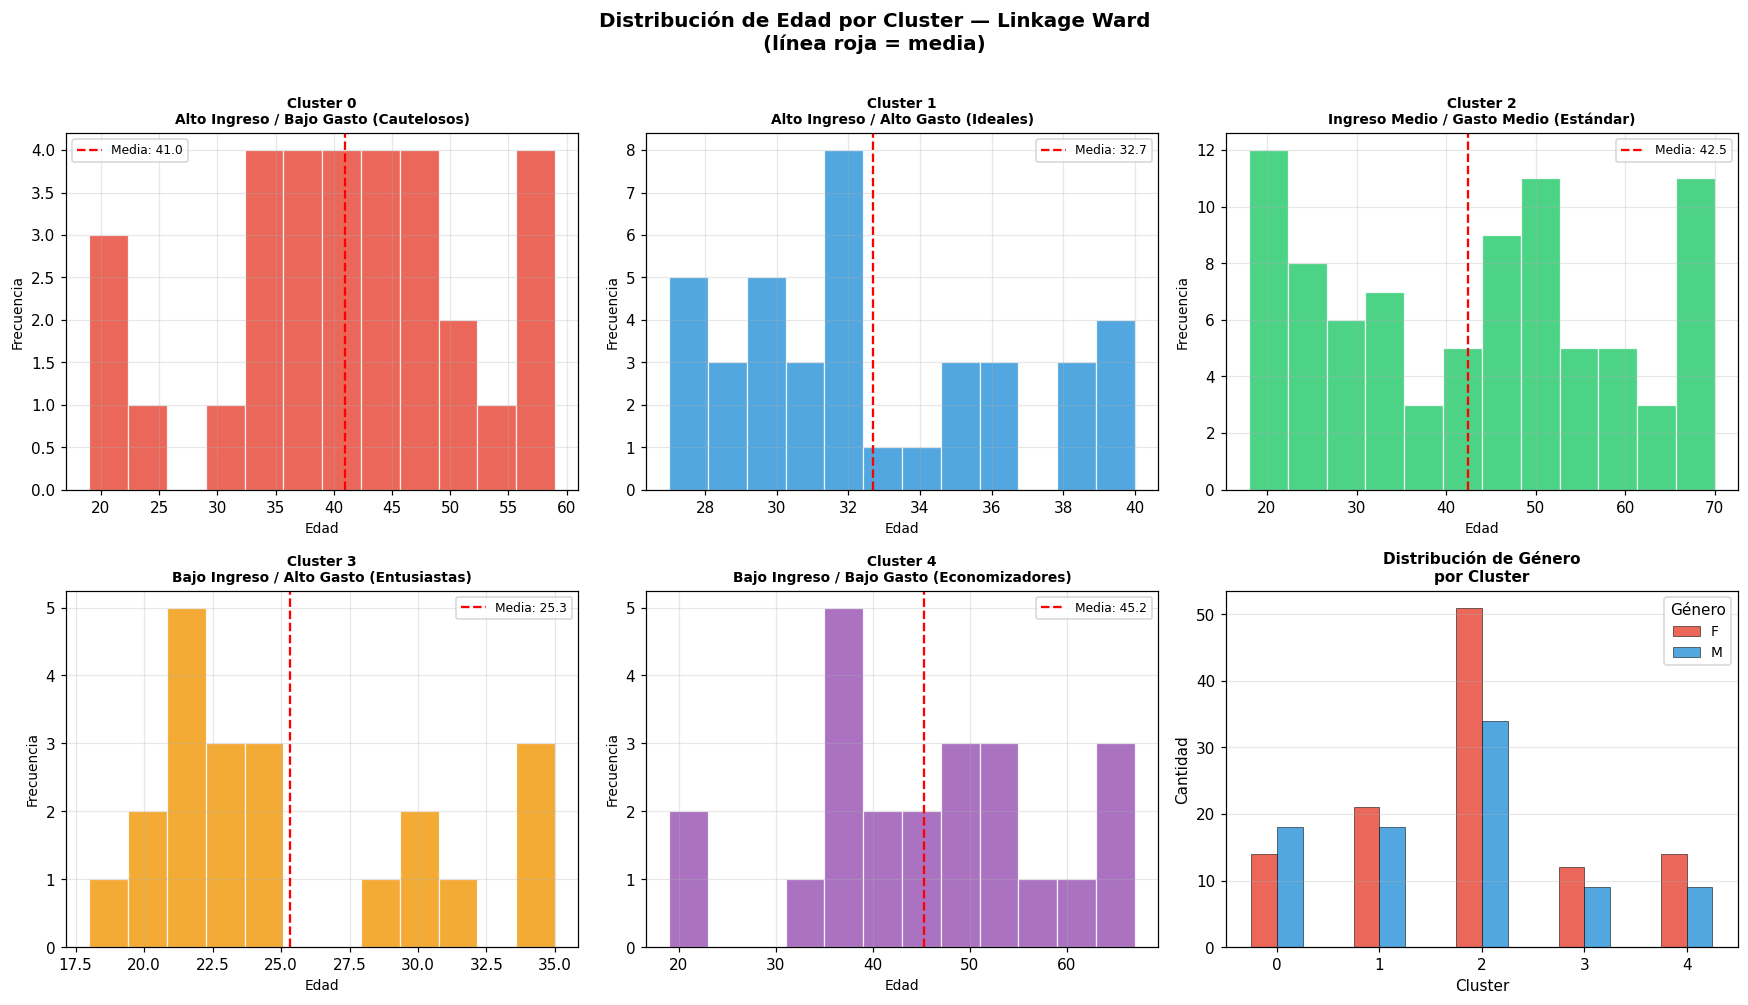

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cluster_ids = sorted(df['Cluster_Ward'].unique())

# Subplot 1-5: distribución de edad por cluster
for i, (ax, cid) in enumerate(zip(axes.flatten()[:5], cluster_ids)):
    data_cl = df[df['Cluster_Ward'] == cid]['Age']
    ax.hist(data_cl, bins=12, color=PALETTE[cid % len(PALETTE)],
            edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.axvline(data_cl.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {data_cl.mean():.1f}')
    nombre = perfil.loc[cid, 'Segmento']
    ax.set_title(f'Cluster {cid}\n{nombre}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Edad', fontsize=9); ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Subplot 6: proporción de género por cluster
ax_gen = axes[1, 2]
genero_cluster = df.groupby(['Cluster_Ward', 'Gender']).size().unstack(fill_value=0)
genero_cluster.plot(kind='bar', ax=ax_gen, color=['#E74C3C','#3498DB'],
                    edgecolor='k', linewidth=0.4, alpha=0.85, legend=True)
ax_gen.set_title('Distribución de Género\npor Cluster', fontsize=10, fontweight='bold')
ax_gen.set_xlabel('Cluster'); ax_gen.set_ylabel('Cantidad')
ax_gen.tick_params(axis='x', rotation=0)
ax_gen.grid(True, axis='y', alpha=0.3)
ax_gen.legend(title='Género', fontsize=9)

fig.suptitle('Distribución de Edad por Cluster — Linkage Ward\n(línea roja = media)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [33]:
# Tabla resumen completa de cada cluster
resumen_completo = df.groupby('Cluster_Ward').agg(
    Segmento=('Segmento', 'first'),
    N_Clientes=('CustomerID','count'),
    Edad_Prom=('Age','mean'),
    Ingreso_Prom=('Annual Income (k$)','mean'),
    Score_Prom=('Spending Score (1-100)','mean'),
    Pct_Femenino=('Gender', lambda x: (x=='F').mean()*100)
).round(1)

print('Tabla Resumen Completa — Linkage Ward (k=5):')
print()
resumen_completo

Tabla Resumen Completa — Linkage Ward (k=5):



,Segmento,N_Clientes,Edad_Prom,Ingreso_Prom,Score_Prom,Pct_Femenino
Cluster_Ward,,,,,,
0,Alto Ingreso / Bajo Gasto (Cautelosos),32,41.0,89.4,15.6,43.8
1,Alto Ingreso / Alto Gasto (Ideales),39,32.7,86.5,82.1,53.8
2,Ingreso Medio / Gasto Medio (Estándar),85,42.5,55.8,49.1,60.0
3,Bajo Ingreso / Alto Gasto (Entusiastas),21,25.3,25.1,80.0,57.1
4,Bajo Ingreso / Bajo Gasto (Economizadores),23,45.2,26.3,20.9,60.9


## 9. Análisis con 3 variables (Age + Income + Score)

Silhouette con 2 variables (Ingreso + Score) : 0.5538
Silhouette con 3 variables (Age+Ingreso+Score): 0.3900



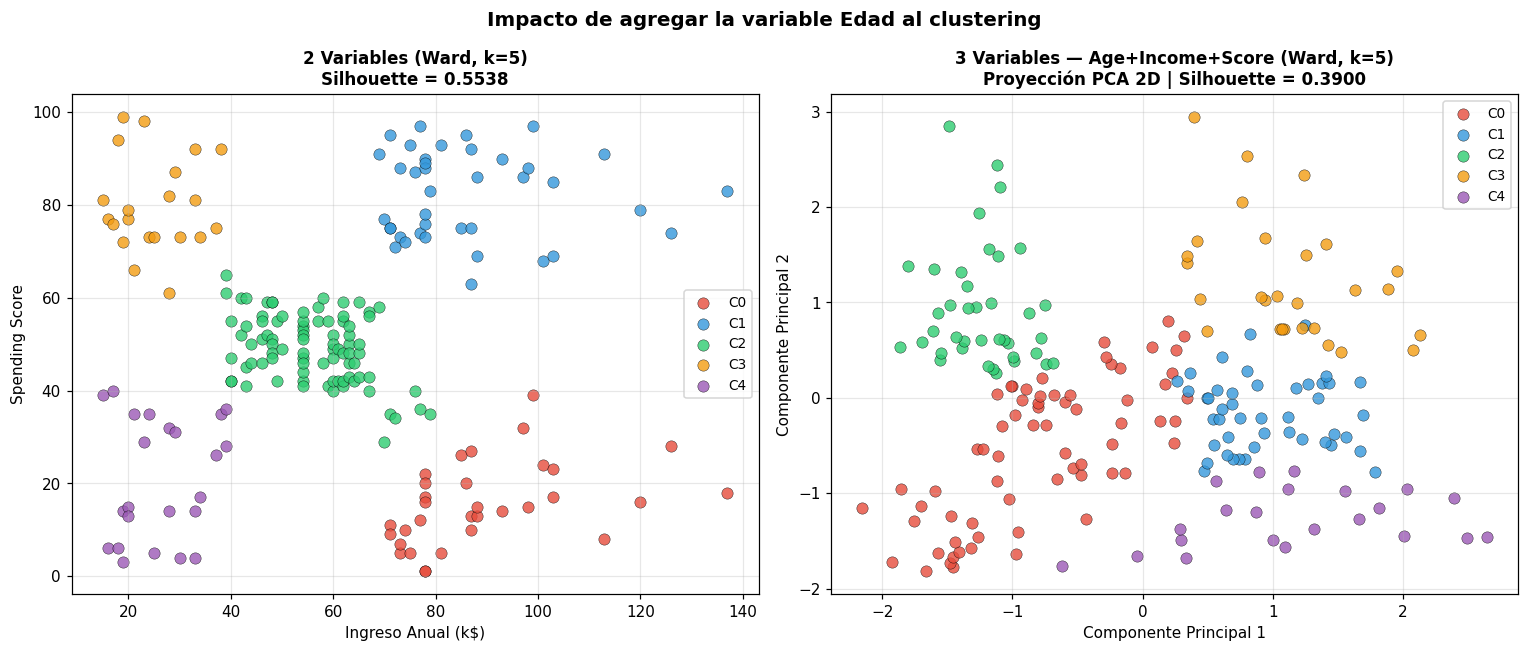

In [34]:
# Clustering con 3 variables usando Ward
modelo_3d = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_3d = modelo_3d.fit_predict(X3_scaled)
df['Cluster_3D'] = labels_3d

sil_3d = silhouette_score(X3_scaled, labels_3d)
sil_2d = silhouette_score(X2_scaled, etiquetas['ward'])

print(f'Silhouette con 2 variables (Ingreso + Score) : {sil_2d:.4f}')
print(f'Silhouette con 3 variables (Age+Ingreso+Score): {sil_3d:.4f}')
print()

# Reducir a 2D con PCA para visualizar el espacio 3D
pca = PCA(n_components=2, random_state=42)
X3_pca = pca.fit_transform(X3_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 2D original
for cid in np.unique(etiquetas['ward']):
    mask = etiquetas['ward'] == cid
    ax1.scatter(X2[mask,0], X2[mask,1], c=PALETTE[cid%len(PALETTE)],
                label=f'C{cid}', s=55, alpha=0.8, edgecolors='k', linewidths=0.3)
ax1.set_title(f'2 Variables (Ward, k=5)\nSilhouette = {sil_2d:.4f}',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Ingreso Anual (k$)'); ax1.set_ylabel('Spending Score')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# 3D → PCA 2D
for cid in np.unique(labels_3d):
    mask = labels_3d == cid
    ax2.scatter(X3_pca[mask,0], X3_pca[mask,1], c=PALETTE[cid%len(PALETTE)],
                label=f'C{cid}', s=55, alpha=0.8, edgecolors='k', linewidths=0.3)
ax2.set_title(f'3 Variables — Age+Income+Score (Ward, k=5)\nProyección PCA 2D | Silhouette = {sil_3d:.4f}',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Componente Principal 1'); ax2.set_ylabel('Componente Principal 2')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

fig.suptitle('Impacto de agregar la variable Edad al clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Resumen ejecutivo y hallazgos

In [37]:
print('=' * 72)
print('   RESUMEN EJECUTIVO — SEGMENTACIÓN DE CLIENTES (MALL CUSTOMERS)')
print('=' * 72)
print()
print('COMPARACIÓN DE LINKAGES (k=5):')
print(df_metricas.to_string())
print()
print('─' * 72)
print()
print('HALLAZGOS POR LINKAGE:')
print()
print('  WARD — MEJOR RESULTADO GENERAL')
print('     • Minimiza la varianza intra-cluster → clusters MÁS COMPACTOS')
print('     • Produce grupos EQUILIBRADOS en tamaño')
print('     • Identifica los 5 segmentos clásicos de mall (cuadrantes de')
print('       ingreso/gasto + segmento medio)')
print('     • Recomendado para la mayoría de casos de segmentación de clientes')
print()
print('  COMPLETE — SEGUNDO MEJOR')
print('     • Usa la distancia MÁXIMA entre puntos de dos clusters')
print('     • Evita el "efecto cadena" del Single linkage')
print('     • Genera clusters compactos pero puede ser sensible a outliers')
print('     • Resultados similares a Ward en datasets bien separados')
print()
print('  AVERAGE — RESULTADO INTERMEDIO')
print('     • Compromiso entre Single y Complete')
print('     • Menos sensible a outliers que Complete')
print('     • Clusters ligeramente menos compactos que Ward y Complete')
print()
print('  SINGLE — PEOR RESULTADO (efecto cadena)')
print('     • Usa la distancia MÍNIMA → muy sensible a outliers')
print('     • Efecto "chaining": un punto cercano a dos clusters los fusiona')
print('     • Produce clusters de forma alargada y elongada')
print('     • Genera clusters MUY DESBALANCEADOS (ej: 1 cluster con 190 puntos)')
print('     • Solo útil para detectar outliers o clusters de forma muy irregular')
print()
print('─' * 72)
print()
print('SEGMENTOS IDENTIFICADOS (Ward, k=5):')
for cid in sorted(df['Cluster_Ward'].unique()):
    r = resumen_completo.loc[cid]
    print(f'  Cluster {cid} | {r["Segmento"]}')
    print(f'    N={int(r["N_Clientes"])} | Edad={r["Edad_Prom"]} | '
          f'Ingreso=${r["Ingreso_Prom"]}k | Score={r["Score_Prom"]} | '
          f'%F={r["Pct_Femenino"]}%')
print()
print('─' * 72)
print()
print('RECOMENDACIONES DE NEGOCIO:')
print('  1. Clientes con Alto Ingreso / Alto Gasto → Programas VIP y fidelización')
print('  2. Clientes con Alto Ingreso / Bajo Gasto → Campañas de activación')
print('     y ofertas personalizadas para incrementar su frecuencia de compra')
print('  3. Clientes con Bajo Ingreso / Alto Gasto → Programas de financiamiento')
print('     y cuotas para mantener su entusiasmo de compra')
print('  4. Segmento Medio → Estrategias de up-selling y cross-selling')
print('  5. Bajo Ingreso / Bajo Gasto → Descuentos y promociones de precio')
print('=' * 72)

   RESUMEN EJECUTIVO — SEGMENTACIÓN DE CLIENTES (MALL CUSTOMERS)

COMPARACIÓN DE LINKAGES (k=5):
          Clusters  Silhouette ↑  Calinski-Harabasz ↑  Davies-Bouldin ↓
Linkage                                                                
Ward             5        0.5538               244.41            0.5779
Complete         5        0.5531               247.21            0.5680
Average          5        0.4794               143.59            0.6433
Single           5        0.2758                 5.65            0.4231

────────────────────────────────────────────────────────────────────────

HALLAZGOS POR LINKAGE:

  WARD — MEJOR RESULTADO GENERAL
     • Minimiza la varianza intra-cluster → clusters MÁS COMPACTOS
     • Produce grupos EQUILIBRADOS en tamaño
     • Identifica los 5 segmentos clásicos de mall (cuadrantes de
       ingreso/gasto + segmento medio)
     • Recomendado para la mayoría de casos de segmentación de clientes

  COMPLETE — SEGUNDO MEJOR
     • Usa la distanci